In this notebook we will implement a neural network that can learn the parameters of a linear optimization problem. 

# Part 1: data obtaining and preprocessing

In [1]:
import numpy as np
import deep_inv_opt as io
import deep_inv_opt.plot as iop
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from diffcp import SolverError
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import contextlib
import io as io2


import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.max_open_warning'] = 0  # Let the plots flow!
%matplotlib inline

In [2]:
u_train = io.tensor(np.linspace(-1.5, 1.5, 1024).reshape((-1, 1)))

In [3]:
u_train, u_val = train_test_split(u_train, test_size=0.2, random_state=42)

u_train, u_test = train_test_split(u_train, test_size=0.15, random_state=42)

Now we generate the data from the real problem.

In [4]:
class ExamplePLP(io.ParametricLP):
    # Generate an LP from a given feature vector u and weight vector w.
    def generate(self, u, w):
        c = [[torch.cos(w[0] + w[1]*u)],
             [torch.sin(w[0] + w[1]*u)]]

        A_ub = [[-1.0,  0.0],
                [ 0.0, -1.0],
                [ w[0], 1 + w[1]*u/3]]

        b_ub = [[ 0.2*w[0]*u],
                [-0.2*w[1]*u],
                [ w[0] + 0.1*u]]
        
        return c, A_ub, b_ub, None, None

In [5]:
plp_true = ExamplePLP(weights=[1.0, 1.0])

# Generate training targets by solve the true PLP.
x_train = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_train])
# torch.save(x_train, "x_train.pt")

x_val = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_val])
# torch.save(x_val, "x_val.pt")

x_test = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_test])
# torch.save(x_test, "x_test.pt")

In [6]:
# x_val = torch.load("x_val.pt")
x_val

tensor([[-0.0079,  0.0079],
        [ 0.0906, -0.0906],
        [ 0.0396, -0.0396],
        [ 0.2818,  1.0886],
        [-0.0624,  0.0625],
        [-0.0443,  0.0443],
        [ 0.0378, -0.0378],
        [ 0.9063,  0.1305],
        [ 0.2554,  1.0741],
        [ 0.9164,  0.1194],
        [ 0.0830, -0.0830],
        [ 0.2589,  1.0759],
        [-0.0970,  0.0971],
        [ 0.2408,  1.0670],
        [-0.0642,  0.0642],
        [-0.0830,  0.0830],
        [ 0.1358, -0.1358],
        [ 0.0507, -0.0507],
        [ 0.0631, -0.0630],
        [ 0.8980,  0.1393],
        [ 0.2437,  1.0684],
        [ 0.7980,  0.2290],
        [ 0.1469, -0.1469],
        [ 0.1170, -0.1170],
        [-0.0108,  0.0109],
        [-0.1080,  0.1082],
        [ 0.0877, -0.0877],
        [ 0.1305, -0.1305],
        [ 0.8098,  0.2197],
        [ 0.7208,  0.2859],
        [-0.0583,  0.0584],
        [-0.1075,  0.1076],
        [ 0.7122,  0.2918],
        [ 0.1082, -0.1082],
        [ 0.0589, -0.0589],
        [ 0.1323, -0

In [7]:
# x_train = torch.load("x_train.pt")
x_train

tensor([[-0.0325,  0.0326],
        [ 0.8569,  0.1792],
        [ 0.7139,  0.2906],
        ...,
        [-0.1000,  0.1000],
        [ 0.1997, -0.1958],
        [-0.0542,  0.0543]], dtype=torch.float64)

In [8]:
# x_test = torch.load("x_test.pt")
x_test

tensor([[ 7.7452e-01,  2.4722e-01],
        [ 7.7839e-01,  2.4428e-01],
        [ 2.2376e-01,  1.0594e+00],
        [ 7.3008e-01,  2.7948e-01],
        [ 7.0679e-02, -7.0669e-02],
        [ 2.1613e-01,  1.0563e+00],
        [ 1.6863e-01, -1.6859e-01],
        [-2.9607e-02,  2.9624e-02],
        [ 1.9854e-01, -1.9775e-01],
        [ 1.2816e-01, -1.2814e-01],
        [-9.0834e-03,  9.0953e-03],
        [ 2.5602e-01,  1.0744e+00],
        [ 5.4843e-02, -5.4834e-02],
        [ 8.4044e-01,  1.9385e-01],
        [ 9.0033e-02, -9.0023e-02],
        [-8.1787e-02,  8.1823e-02],
        [ 2.7302e-01,  1.0835e+00],
        [ 5.6603e-02, -5.6593e-02],
        [ 1.9091e-01, -1.9080e-01],
        [ 9.0191e-01,  1.3519e-01],
        [ 5.1324e-02, -5.1315e-02],
        [ 2.0792e-01,  1.0529e+00],
        [-4.3094e-02,  4.3114e-02],
        [ 9.7071e-02, -9.7060e-02],
        [ 1.9150e-01, -1.9138e-01],
        [-7.3582e-02,  7.3612e-02],
        [-3.8403e-02,  3.8422e-02],
        [ 5.1911e-02, -5.190

# Part 2: model definition and training

In [9]:
# Check if we are using a GPU or CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [10]:
learning_rate = 1e-3
batch_size = 16

In [11]:
# Dataset and DataLoader definition
class UDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data.clone().to(dtype=torch.float32) 
        self.targets = targets.clone().to(dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

# Dataset (u, x)
dataset = UDataset(u_train, x_train)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [12]:
val_dataset = UDataset(u_val, x_val)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

test_dataset = UDataset(u_test, x_test)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [13]:
def gradient_descent_solver(c, A, b, lr=0.01, max_iter=1000, tol=1e-6, M=1000.0):
    """
    Solve a linear optimization problem with constraints using gradient descent.

    Parameters:
    - c: Cost vector (n,)
    - A: Constraint matrix (m, n)
    - b: Constraint vector (m,)
    - lr: Learning rate
    - max_iter: Maximum number of iterations
    - tol: Convergence tolerance

    Returns:
    - x: Optimal solution found
    """
    n = c.shape[0]
    x = torch.zeros(n, dtype=c.dtype, requires_grad=True)
    optimizer = torch.optim.SGD([x], lr=lr)

    for _ in range(max_iter):
        optimizer.zero_grad()
        objective = torch.dot(c, x) + M * torch.sum(torch.relu(A @ x - b)) # relu(x) = max(0, x)
        objective.backward(retain_graph=True)
        optimizer.step()

        if torch.norm(x.grad) < tol:
            break
    return x

def newton_solver(c, A, b, max_iter=100, tol=1e-6, M=1000.0):
    """
    Solve a linear optimization problem with constraints using the Newton method.

    Parameters:
    - c: Cost vector (n,)
    - A: Constraint matrix (m, n)
    - b: Constraint vector (m,)
    - max_iter: Maximum number of iterations
    - tol: Convergence tolerance

    Returns:
    - x: Optimal solution found
    """
    n = c.shape[0]
    x = torch.zeros(n, dtype=c.dtype, requires_grad=True)
    
    for _ in range(max_iter):
        loss = torch.dot(c, x) + M * torch.sum(torch.relu(A @ x - b))

        # Gradient and Hessian
        grad = torch.autograd.grad(loss, x, create_graph=True)[0]
        hess = torch.autograd.functional.hessian(lambda y: torch.dot(c, y) + M * torch.sum(torch.relu(A @ y - b)), x)

        # Newton step: Δx = -H⁻¹ * grad
        try:
            delta_x = torch.linalg.solve(hess, -grad)
        except RuntimeError:
            break  # Break if the Hessian is singular

        # Actualize x
        x = x + delta_x

        # Break if converged
        if torch.norm(delta_x) < tol:
            break

    return x


In [14]:
def solver(c_, A_, b_):
    try:
        M = 1000.0
        m, n = A_.shape

        A = cp.Parameter((m, n))
        b = cp.Parameter(m)
        c = cp.Parameter(n)
        x = cp.Variable(n)

        obj = cp.Minimize(c.T @ x + M * cp.sum(cp.pos(A @ x - b))) # cp.pos = max(0, x)

        cons = [0 * x >= 0]

        prob = cp.Problem(obj, cons)
        layer = CvxpyLayer(prob, parameters=[c, A, b], variables=[x])

        with io2.StringIO() as buf, contextlib.redirect_stdout(buf):
            solution, = layer(c_, A_, b_)
        return solution

    except SolverError:
        return newton_solver(c_, A_, b_)
    

In [15]:
# Define the model
class ParametricLPNet(nn.Module):
    def __init__(self):
        super(ParametricLPNet, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(1, 12),
            nn.ReLU(),
            nn.Linear(12, 40),
            nn.ReLU(),
            nn.Linear(40, 150),
            nn.ReLU(),
            nn.Linear(150, 300),
            nn.ReLU(),
            nn.Linear(300, 150),
            nn.ReLU(),
            nn.Linear(150, 90),
            nn.ReLU(),
            nn.Linear(90, 40),
            nn.Sigmoid(),
            nn.Linear(40, 14)
        )
    def forward(self, u):
        output = self.fc(u)        
        c = output[:, 0:2]
        A = output[:, 2:10].reshape(-1, 4, 2)
        b = output[:, 10:14]
        return torch.stack(list(map(solver, c, A, b)))

In [16]:
loss_fn = nn.MSELoss()

In [17]:
model = ParametricLPNet()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # elegir una de las dos

In [18]:
model

ParametricLPNet(
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=150, bias=True)
    (5): ReLU()
    (6): Linear(in_features=150, out_features=300, bias=True)
    (7): ReLU()
    (8): Linear(in_features=300, out_features=150, bias=True)
    (9): ReLU()
    (10): Linear(in_features=150, out_features=90, bias=True)
    (11): ReLU()
    (12): Linear(in_features=90, out_features=40, bias=True)
    (13): Sigmoid()
    (14): Linear(in_features=40, out_features=14, bias=True)
  )
)

In [19]:
# Initialize the weights of the model
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu') # inicializamos los pesos de la red con Kaiming
        nn.init.zeros_(m.bias) # inicializamos los bias a 0

# initialize_weights(model)


# We load the trained model weights
model.load_state_dict(torch.load("model_weights.pth"))

<All keys matched successfully>

In [20]:
def near(rs, x_batch, tol=1e-3):
    '''
    rs: Tensor containing the solutions of the LPs  
    x_batch: Tensor containing the desired solutions of the LPs  
    tol: Tolerance to consider two vectors as equal  

    This function calculates the number of LP solutions that are within a distance  
    less than tol from the desired solutions.
    '''
    d = torch.sum((rs - x_batch) ** 2, dim=1)
    return torch.sum(d < tol).item()

In [21]:
tol = 0.0001

def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    loss_media = 0.0
    accuracy = 0.0
    batch_size = dataloader.batch_size
    for batch, (u_batch, x_batch) in enumerate(dataloader):

        rs = model(u_batch)
        loss = loss_fn(rs, x_batch)

        # Backpropagation and optimization
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 8 == 0:
            loss = loss.item()
            current = batch * batch_size + batch_size
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
            
        loss_media += loss
        accuracy += near(rs, x_batch, tol)

    return loss_media / num_batches, accuracy / size

In [22]:
def val_loop(dataloader, model, loss_fn):
    model.eval()
    size=len(dataloader.dataset)
    num_batches = len(dataloader)
    val_loss, correct = 0, 0

    for u_batch, x_batch in dataloader:
        rs = model(u_batch)
        val_loss += loss_fn(rs, x_batch).item()
        correct += near(rs, x_batch, tol) # correct is the number of LP solutions that are within a distance less than tol from the desired solutions.
    val_loss /= num_batches
    correct /= size
    print(f"Validation Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {val_loss:>8f} \n\n")
    return val_loss, correct

In [23]:
val_acc = []
val_loss = []
train_acc = []
train_loss = []

train_acc = torch.load("train_acc.pth")
val_acc = torch.load("val_acc.pth")
train_loss = torch.load("train_loss.pth")
val_loss = torch.load("val_loss.pth")

In [101]:
# Entrenamiento
epochs = 1

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    loss, accuracy = train_loop(dataloader, model, loss_fn, optimizer)
    train_acc.append(accuracy)
    train_loss.append(loss.clone().detach())
    print(f"\nTraining Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {loss:>8f} \n")
    
    loss_val, accuracy_val = val_loop(val_dataloader, model, loss_fn)
    val_acc.append(accuracy_val)
    val_loss.append(loss_val)

print("Done!")

Epoch 1
-------------------------------
loss: 0.000139  [   16/  696]
loss: 0.000127  [  144/  696]
loss: 0.008852  [  272/  696]
loss: 0.000221  [  400/  696]
loss: 0.000206  [  528/  696]
loss: 0.000207  [  656/  696]

Training Error: 
 Accuracy: 30.7%, Avg loss: 0.002772 

Validation Error: 
 Accuracy: 69.3%, Avg loss: 0.002392 


Done!


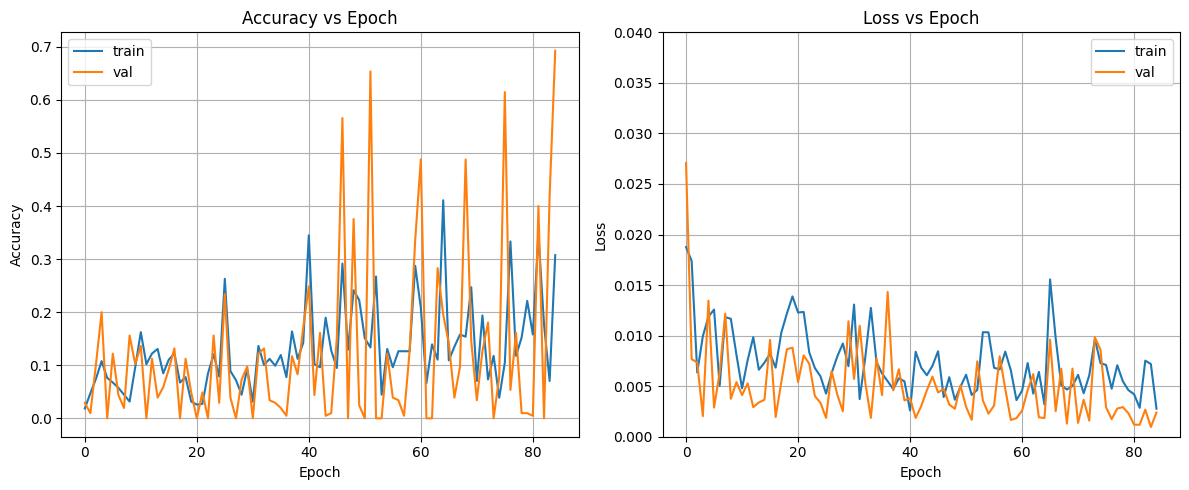

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (Accuracy vs Epoch)
axes[0].plot(train_acc, label="train")
axes[0].plot(val_acc, label="val")
axes[0].legend()
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs Epoch")
axes[0].grid()
axes[1].set_ylim(0, 1)

# (Loss vs Epoch)
axes[1].plot(train_loss, label="train")
axes[1].plot(val_loss, label="val")
axes[1].legend()
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss vs Epoch")
axes[1].grid()
axes[1].set_ylim(0, 0.04)

plt.tight_layout()
plt.show()

In [103]:
torch.save(model.state_dict(), "model_weights.pth")

In [104]:
# save the accuracy 
torch.save(train_acc, "train_acc.pth")
torch.save(val_acc, "val_acc.pth")
torch.save(train_loss, "train_loss.pth")
torch.save(val_loss, "val_loss.pth")

## Evaluation of the model on the test set

In [25]:
model.eval()

ParametricLPNet(
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=150, bias=True)
    (5): ReLU()
    (6): Linear(in_features=150, out_features=300, bias=True)
    (7): ReLU()
    (8): Linear(in_features=300, out_features=150, bias=True)
    (9): ReLU()
    (10): Linear(in_features=150, out_features=90, bias=True)
    (11): ReLU()
    (12): Linear(in_features=90, out_features=40, bias=True)
    (13): Sigmoid()
    (14): Linear(in_features=40, out_features=14, bias=True)
  )
)

In [26]:
u = torch.tensor([[0.25]], dtype=torch.float64)
x = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u])
u,x

(tensor([[0.2500]], dtype=torch.float64),
 tensor([[-0.0500,  0.0500]], dtype=torch.float64))

In [41]:
x_pred = model(torch.tensor([[0.25]]))
x_pred

tensor([[-0.0495,  0.0562]], grad_fn=<StackBackward0>)

In [43]:
x, x_pred, torch.norm(x - x_pred)

(tensor([[-0.0500,  0.0500]], dtype=torch.float64),
 tensor([[-0.0495,  0.0562]], grad_fn=<StackBackward0>),
 tensor(0.0063, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>))

In [44]:
val_loop(test_dataloader, model, loss_fn)

Validation Error: 
 Accuracy: 65.9%, Avg loss: 0.000427 




(0.00042700611129475874, 0.6585365853658537)

Now we plot the results of the model on the test set.

In [45]:
def predict(model, dataloader):
    model.eval()
    size=len(dataloader.dataset)
    num_batches = len(dataloader)
    x_pred = torch.empty(0, 2)
    for u_batch, x_batch in dataloader:
        rs = model(u_batch)
        x_pred = torch.cat((x_pred, rs))
    return x_pred.detach()

In [46]:
X_pred = predict(model, test_dataloader)
X_pred

tensor([[ 5.7272e-02, -5.8916e-02],
        [ 2.7285e-01,  1.0942e+00],
        [ 3.0609e-02, -3.0891e-02],
        [ 2.4145e-01,  1.0643e+00],
        [ 2.0635e-01,  1.0095e+00],
        [ 1.3640e-01, -1.3836e-01],
        [ 8.6989e-01,  1.6895e-01],
        [-1.8747e-02,  2.2425e-02],
        [ 9.6335e-02, -1.0110e-01],
        [-2.7800e-02,  3.1842e-02],
        [ 7.3317e-01,  2.8141e-01],
        [ 1.7326e-01, -1.6886e-01],
        [-7.2834e-02,  9.1461e-02],
        [ 7.3621e-01,  2.7865e-01],
        [ 7.6471e-01,  2.5390e-01],
        [-6.1492e-02,  7.1776e-02],
        [-3.8500e-02,  4.3319e-02],
        [ 1.0127e-01, -1.0687e-01],
        [ 2.6628e-01,  1.0863e+00],
        [ 2.2384e-01,  1.0457e+00],
        [ 5.8586e-02, -6.0299e-02],
        [-4.1859e-02,  4.7236e-02],
        [ 8.7153e-01,  1.6767e-01],
        [ 3.7120e-02, -3.7783e-02],
        [-7.1511e-02,  8.6688e-02],
        [ 1.0307e-01, -1.0896e-01],
        [ 8.8857e-01,  1.5469e-01],
        [ 7.3275e-01,  2.818

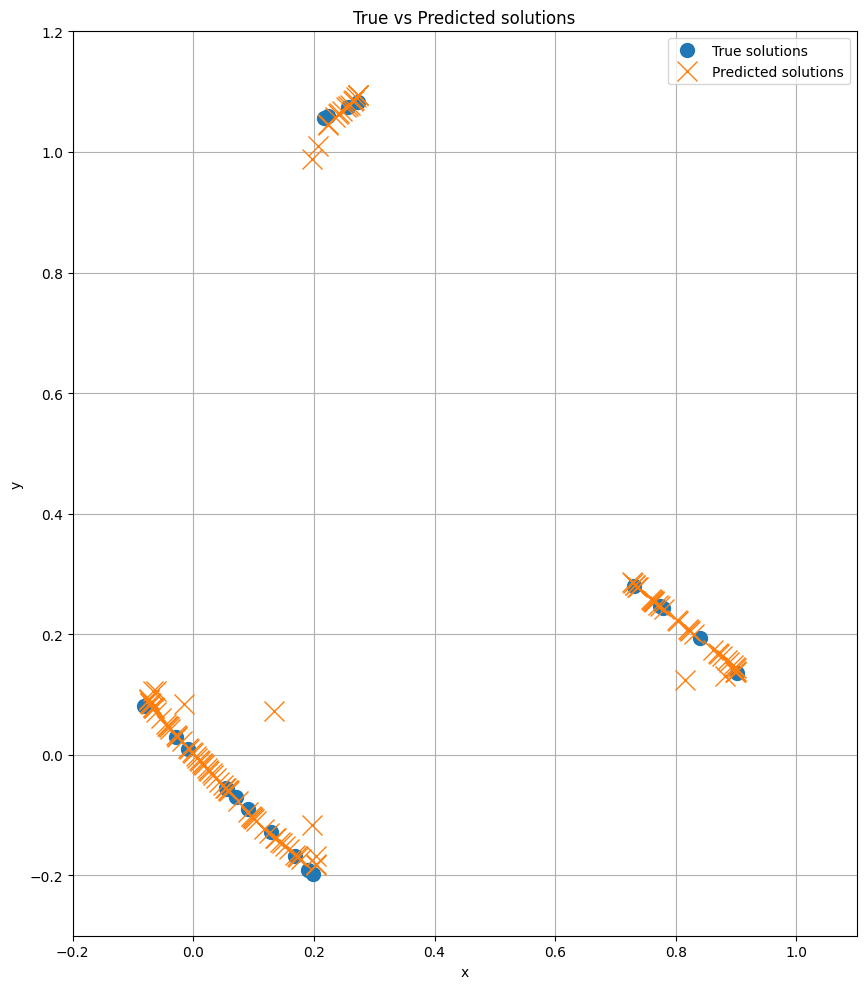

<Figure size 640x480 with 0 Axes>

In [85]:
plt.figure(figsize=(10, 10))
plt.plot(x_test[:20, 0], x_test[:20, 1], 'o', label='True solutions', markersize=10)
plt.plot(X_pred[:, 0], X_pred[:, 1], 'x', label='Predicted solutions', markersize=15)
plt.xlabel('x')
plt.ylabel('y')
plt.title('True vs Predicted solutions')
plt.legend()
plt.grid()
# marco los limites de la x y la y
plt.xlim(-0.2, 1.1)
plt.ylim(-0.3, 1.2)
plt.gca().set_aspect('equal', adjustable='box') # esto es para que los ejes tengan la misma escala
plt.tight_layout()
plt.show()

plt.savefig("true_vs_predicted_nn.png")

# Part 3: Deep IO model

In [75]:
plp_learn = ExamplePLP([1.5, 1.2])

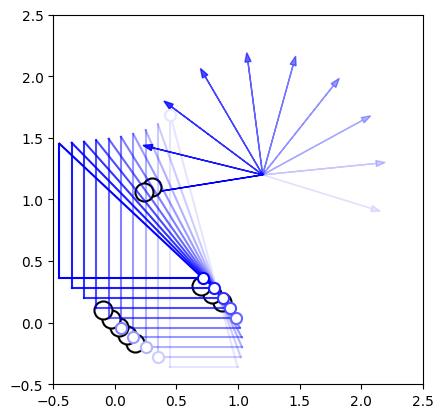

In [ ]:
u_show = io.tensor(np.linspace(-1.5, 1.5, 10).reshape((-1, 1)))
x_show = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_show])

# Data set. Black points are the real solutions, blue points are the solutions of the plp_learn

iop.plot_targets(x_show, markersize=13)
iop.plot_parametric_linprog(plp_learn, u_show, color=[0, 0, 1], xylim=((-0.5,2.5),(-0.5,2.5)), cxy=(1.2,1.2), show_solutions=True)

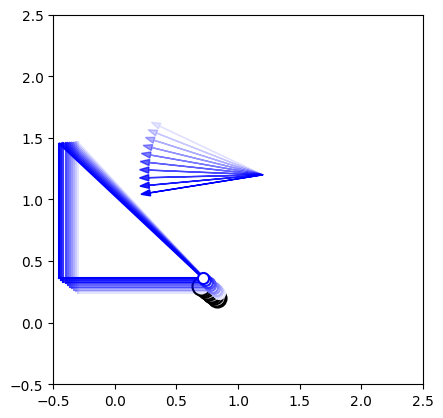

In [78]:
u_show = io.tensor(np.linspace(1, 1.5, 10).reshape((-1, 1)))
x_show = torch.cat([io.linprog(*plp_true(ui)).detach().t() for ui in u_show])

# Data set. Black points are the real solutions, blue points are the solutions of the plp_learn

iop.plot_targets(x_show, markersize=13)
iop.plot_parametric_linprog(plp_learn, u_show, color=[0, 0, 1], xylim=((-0.5,2.5),(-0.5,2.5)), cxy=(1.2,1.2), show_solutions=True)

In [58]:
io.inverse_parametric_linprog(u_train, x_train, plp_learn, max_steps=10,
                              callback=io.inverse_parametric_linprog_step_printer())

inverse_parametric_linprog[0001]: loss=0.360737 weights=[1.5000 1.2000]
inverse_parametric_linprog[0002]: loss=0.350147 weights=[1.3332 0.6538]
inverse_parametric_linprog[0003]: loss=0.274222 weights=[1.2918 0.4963]
inverse_parametric_linprog[0004]: loss=0.273151 weights=[1.2870 0.4853]
inverse_parametric_linprog[0005]: loss=0.273150 weights=[1.2870 0.4852]
inverse_parametric_linprog[0006]: loss=0.273149 weights=[1.2870 0.4853]
inverse_parametric_linprog[0007]: loss=0.273147 weights=[1.2870 0.4852]
inverse_parametric_linprog[0008]: loss=0.273144 weights=[1.2870 0.4852]
inverse_parametric_linprog[0009]: loss=0.273143 weights=[1.2870 0.4851]
inverse_parametric_linprog[0010]: loss=0.273142 weights=[1.2871 0.4851]
inverse_parametric_linprog[done]: loss=0.273140 weights=[1.2871 0.4851]


(<__main__.ExamplePLP at 0x7993613d66c0>,
 tensor(0.2731, dtype=torch.float64, grad_fn=<MeanBackward0>),
 tensor([[-0.0419,  0.0158],
         [ 0.9922,  0.0869],
         [ 0.9776,  0.1410],
         ...,
         [-0.1285,  0.0485],
         [ 0.2570, -0.0969],
         [-0.0698,  0.0263]], dtype=torch.float64, grad_fn=<CatBackward0>))

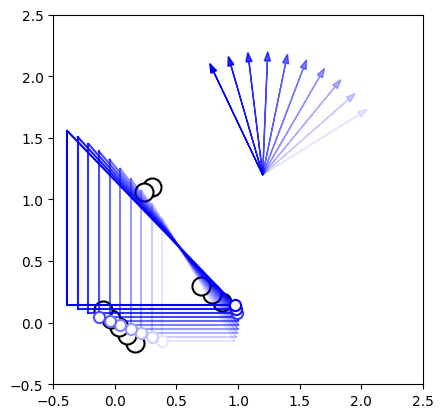

In [60]:
# Plot the new plp_learn, to show that the solutions (blue circles) now line up with the observed targets (black circles).
iop.plot_targets(x_show, markersize=13)
iop.plot_parametric_linprog(plp_learn, u_show, color=[0, 0, 1], xylim=((-0.5,2.5),(-0.5,2.5)), cxy=(1.2,1.2), show_solutions=True)

In [81]:
w = [1.2871, 0.4851]

estimated_plp = ExamplePLP(w)

res = np.array([torch.norm(x - io.linprog(*estimated_plp(u)).t().detach()) for u, x in zip(u_test, x_test)])
acc = sum(res<0.001)
lss = res.mean()
print(f"Test accuracy: {100*acc/len(res):.2f}%")
print(f"Test mean loss: {lss:.4f}")

Test accuracy: 0.81%
Test mean loss: 0.2473


In [82]:
X_pred_io = torch.cat([io.linprog(*estimated_plp(u)).t().detach() for u in u_test])
X_pred_io

tensor([[ 9.8421e-01,  1.1993e-01],
        [ 9.8461e-01,  1.1851e-01],
        [ 2.8800e-01, -1.0854e-01],
        [ 9.7941e-01,  1.3558e-01],
        [ 9.0977e-02, -3.4279e-02],
        [ 2.7818e-01, -1.0484e-01],
        [ 2.1704e-01, -8.1792e-02],
        [-3.8099e-02,  1.4373e-02],
        [ 2.5554e-01, -9.6303e-02],
        [ 1.6496e-01, -6.2160e-02],
        [-1.1682e-02,  4.4152e-03],
        [ 3.2952e-01, -1.2419e-01],
        [ 7.0595e-02, -2.6597e-02],
        [ 9.9075e-01,  9.4039e-02],
        [ 1.1589e-01, -4.3667e-02],
        [-1.0525e-01,  3.9695e-02],
        [ 3.5141e-01, -1.3244e-01],
        [ 7.2860e-02, -2.7450e-02],
        [ 2.4572e-01, -9.2605e-02],
        [ 9.9582e-01,  6.5588e-02],
        [ 6.6066e-02, -2.4890e-02],
        [ 2.6762e-01, -1.0086e-01],
        [-5.5457e-02,  2.0917e-02],
        [ 1.2495e-01, -4.7081e-02],
        [ 2.4648e-01, -9.2889e-02],
        [-9.4692e-02,  3.5712e-02],
        [-4.9419e-02,  1.8641e-02],
        [ 6.6821e-02, -2.517

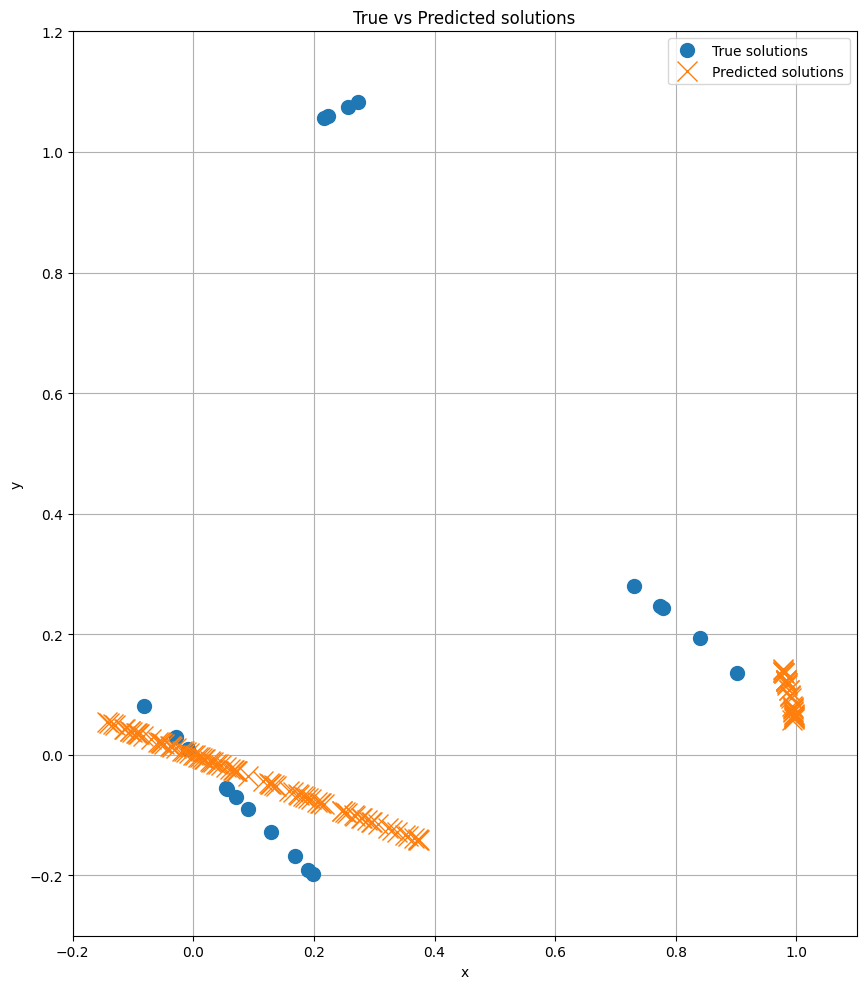

<Figure size 640x480 with 0 Axes>

In [84]:
plt.figure(figsize=(10, 10))
plt.plot(x_test[:20, 0], x_test[:20, 1], 'o', label='True solutions', markersize=10)
plt.plot(X_pred_io[:, 0], X_pred_io[:, 1], 'x', label='Predicted solutions', markersize=15)
plt.xlabel('x')
plt.ylabel('y')
plt.title('True vs Predicted solutions')
plt.legend()
plt.grid()
# marco los limites de la x y la y
plt.xlim(-0.2, 1.1)
plt.ylim(-0.3, 1.2)
plt.gca().set_aspect('equal', adjustable='box') # esto es para que los ejes tengan la misma escala
plt.tight_layout()
plt.show()

plt.savefig("true_vs_predicted_io.png")